In [35]:
import polars as pl
import torch
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from model import *
#from model2 import *
from visualization import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example: Gaussian Blobs

In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

### Prepare dataset

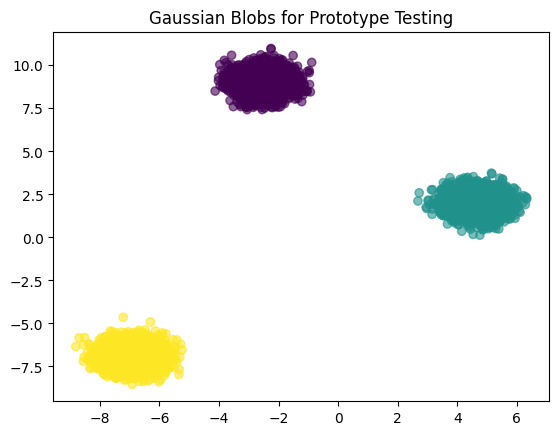

In [3]:
X, y = make_blobs(n_samples=10000, centers=3, cluster_std=0.5, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.title("Gaussian Blobs for Prototype Testing")
plt.show()

In [4]:
scaler = StandardScaler()

In [5]:
X = scaler.fit_transform(X)

In [6]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [7]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
print(len(train_loader))

250


### Prepare model

In [12]:
model = ProtoPNet(2 , hidden_layers=[], num_prototypes=3, num_classes=3, latent_dim=2)

In [68]:
model.encoder = nn.Identity()

In [69]:
model

ProtoPNet(
  (encoder): Identity()
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=3, out_features=3, bias=False)
)

### Train model

In [70]:
train_protopnet(model, train_loader, test_loader, epochs=5, lr=0.001, class_weights=None, lambda_clst=0.8, lambda_sep=0.08)

None

Epoch 1/5


Epoch 1/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.3923
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.2745639841556549
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.2296
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Epoch 2/5


Epoch 2/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 0.1254
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.05367964205145836
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.0416
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Epoch 3/5


...

Phase 1 - Training Loss: -0.0384
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.022815281584858894
Phase 3 - Last Layer Optimization Completed
Epoch 3: Val Loss = 0.0173
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Epoch 4/5


Epoch 4/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.0598
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.012434116069227457
Phase 3 - Last Layer Optimization Completed
Epoch 4: Val Loss = 0.0095
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Epoch 5/5


Epoch 5/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.0675
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.007131232949905098
Phase 3 - Last Layer Optimization Completed
Epoch 5: Val Loss = 0.0056
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [71]:
print(model.proto_layer.prototypes)

Parameter containing:
tensor([[-0.2066,  1.1890],
        [ 1.3155,  0.0837],
        [-1.1056, -1.2668]], requires_grad=True)


### Verify that prototypes are datapoints from training data

In [72]:
model.eval()
with torch.no_grad():
    z_test, distances, y_logits = model(X_test)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)
print(distances.shape)

(2000,)
(2000, 2)
torch.Size([2000, 3])


In [73]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()

In [74]:
model.eval()
#X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

for i, dist in enumerate(distances):
    print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")

Prototype 0: Closest training point at index 3528, Distance: 0.0000
Prototype 1: Closest training point at index 4706, Distance: 0.0000
Prototype 2: Closest training point at index 6449, Distance: 0.0000


### Visualize prototypes along with training data

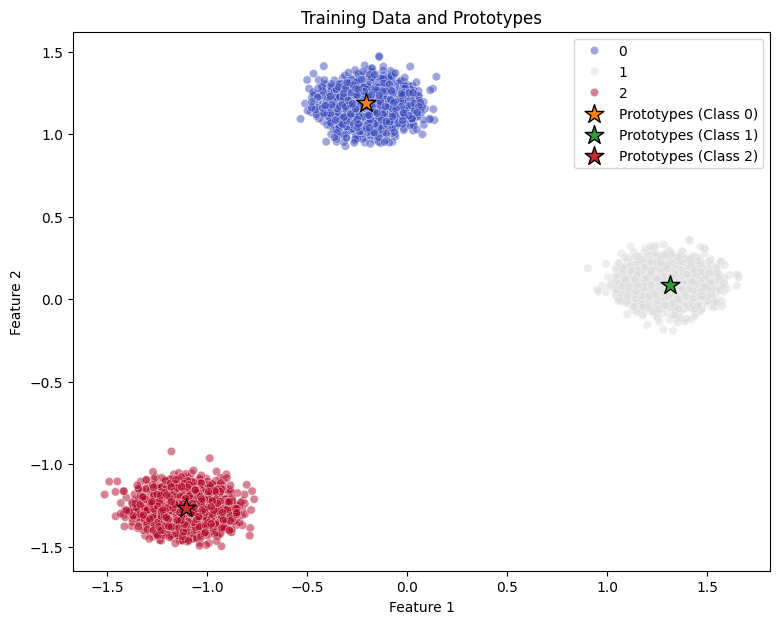

In [76]:
# Set up plot
prototype_labels = model.proto_layer.prototype_labels
plt.figure(figsize=(9, 7))

# Plot training data
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, alpha=0.5, palette="coolwarm")

# Plot prototypes
for proto_class in np.unique(prototype_labels):
    class_mask = prototype_labels == proto_class
    plt.scatter(prototypes[class_mask, 0], 
                prototypes[class_mask, 1], 
                marker='*', s=200, edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data and Prototypes")
plt.legend()
plt.savefig('figs/ppnet/gauss_blobs_example.png')
plt.show()


In [13]:
model


ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=2, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=2, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=3, out_features=3, bias=False)
)

In [ ]:
train_protopnet(model, train_loader, test_loader, epochs=3, lr=0.001, class_weights=None, lambda_clst=0.8, lambda_sep=0.08)

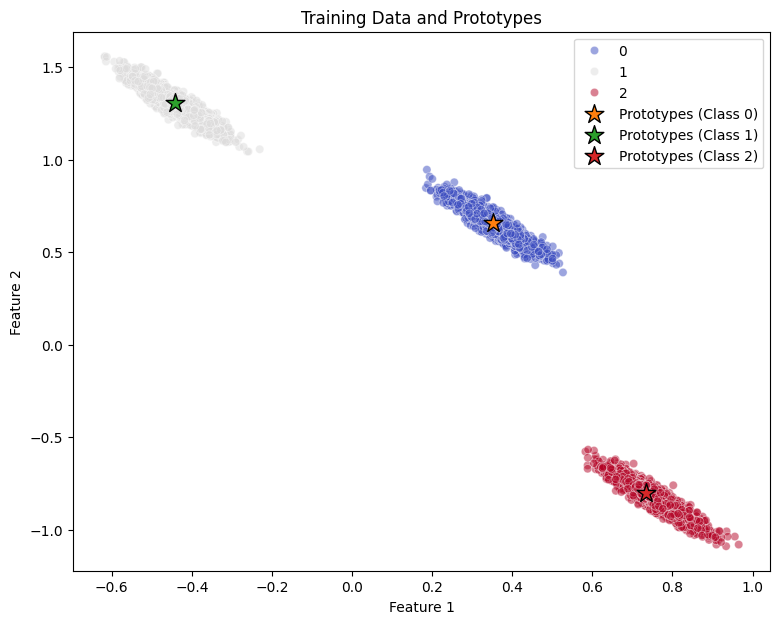

In [20]:
# Set up plot
prototype_labels = model.proto_layer.prototype_labels
plt.figure(figsize=(9, 7))

# Plot training data
sns.scatterplot(x=z_test[:, 0], y=z_test[:, 1], hue=y_train, alpha=0.5, palette="coolwarm")

# Plot prototypes
for proto_class in np.unique(prototype_labels):
    class_mask = prototype_labels == proto_class
    plt.scatter(prototypes[class_mask, 0], 
                prototypes[class_mask, 1], 
                marker='*', s=200, edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data and Prototypes")
plt.legend()
plt.savefig('figs/ppnet/gauss_blobs_example.png')
plt.show()


In [39]:
model = ProtoPNet(2 , hidden_layers=[4, 2], num_prototypes=3, num_classes=3, latent_dim=2)
model

ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=4, bias=True)
      (1): Tanh()
      (2): Linear(in_features=4, out_features=2, bias=True)
      (3): Tanh()
      (4): Linear(in_features=2, out_features=2, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=2, bias=True)
      (1): Tanh()
      (2): Linear(in_features=2, out_features=4, bias=True)
      (3): Tanh()
      (4): Linear(in_features=4, out_features=2, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=3, out_features=3, bias=False)
)

In [ ]:
train_protopnet(model, train_loader, test_loader, epochs=3, X_triplet=X_triplet,  lr=0.001, class_weights=None, lambda_clst=0.8, lambda_sep=0.08)

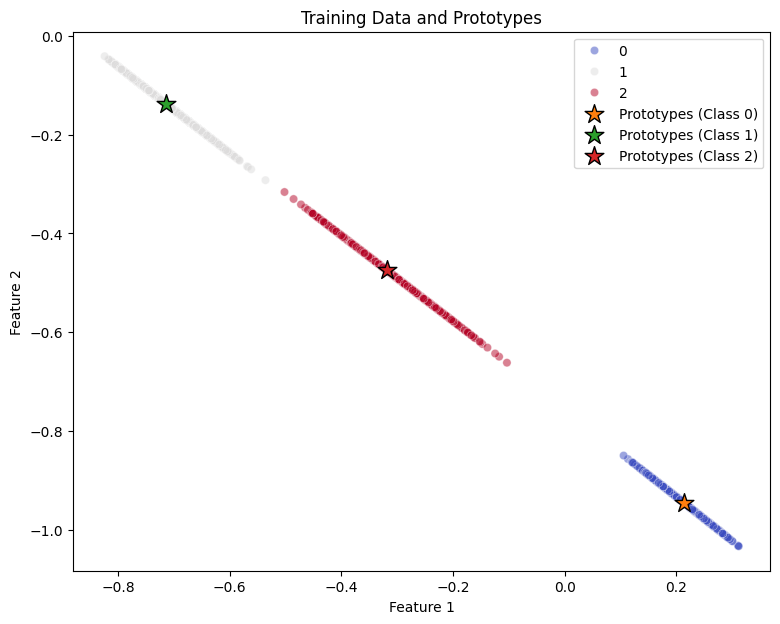

In [42]:
# Set up plot
prototype_labels = model.proto_layer.prototype_labels
plt.figure(figsize=(9, 7))

# Plot training data
sns.scatterplot(x=z_test[:, 0], y=z_test[:, 1], hue=y_train, alpha=0.5, palette="coolwarm")

# Plot prototypes
for proto_class in np.unique(prototype_labels):
    class_mask = prototype_labels == proto_class
    plt.scatter(prototypes[class_mask, 0], 
                prototypes[class_mask, 1], 
                marker='*', s=200, edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data and Prototypes")
plt.legend()
plt.savefig('figs/ppnet/gauss_blobs_example_actfn.png')
plt.show()


## Example: XOR Dataset

### Prepare data and model

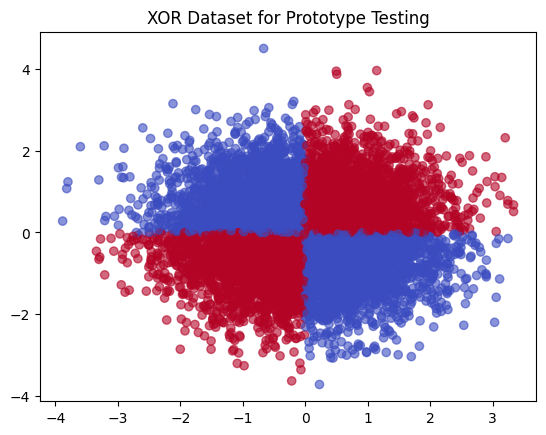

In [42]:
np.random.seed(42)
X = np.random.randn(10000, 2)
y = (X[:, 0] * X[:, 1] > 0).astype(int)  # XOR condition

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("XOR Dataset for Prototype Testing")
plt.show()

In [43]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(len(train_loader))

250


In [50]:
model_identity = ProtoPNet(2, hidden_layers=[], num_prototypes=4, num_neg=2, num_classes=2, latent_dim=2)
model_identity.encoder = nn.Identity()
print(model_identity)
model_identity.proto_layer.prototype_labels

model_linear = ProtoPNet(2 , hidden_layers=[], num_prototypes=4, num_neg=2, num_classes=2, latent_dim=2)
#model_linear.encoder = nn.Linear(2, 2)
print(model_linear)

model_nonlin = ProtoPNet(2 , hidden_layers=[4, 2], num_prototypes=4, num_neg=2, num_classes=2, latent_dim=2)
print(model_nonlin)

ProtoPNet(
  (encoder): Identity()
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=2, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=4, out_features=2, bias=False)
)
ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=2, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=2, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=4, out_features=2, bias=False)
)
ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=4, bias=True)
      (1): Tanh()
      (2): Linear(in_features=4, out_features=2, bias=True)
      (3): Tanh()
      (4): Linear(in_features=2, out_features=2, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=2, out_features=2, bias=True

In [45]:
samples = []
labels = []
num_per_type = 2
for anomaly_type in [0,1]:
    indices = np.where(y_train == anomaly_type)[0]
    chosen = np.random.permutation(indices)[:num_per_type]

    # Add to the list
    samples.append(torch.tensor(X_train[chosen], dtype=torch.float32))
    labels.append(torch.tensor(y_train[chosen], dtype=torch.long))

X_triplet = torch.cat(samples, dim=0)
y_triplet = torch.cat(labels)

/tmp/ipykernel_3613744/2600929743.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  samples.append(torch.tensor(X_train[chosen], dtype=torch.float32))
/tmp/ipykernel_3613744/2600929743.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels.append(torch.tensor(y_train[chosen], dtype=torch.long))


### Train model

In [47]:
lambda_triplet = 0.5
filepath = "model_ppnet_triplet_xor.pth"
train_protopnet_triplet(model_identity, 
                        train_loader, 
                        test_loader, 
                        epochs=10, 
                        X_triplet=X_triplet, 
                        y_triplet=y_triplet, 
                        lr=0.001, 
                        class_weights=None, 
                        lambda_triplet=lambda_triplet, 
                        lambda_clst=0.8, 
                        lambda_sep=0.08,
                        filepath=filepath)

0.5

Epoch 1/10


Epoch 1/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 2.5054
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.6318338705301285
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.6339
              precision    recall  f1-score   support

           0       0.51      0.63      0.56       988
           1       0.53      0.41      0.47      1012

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.51      2000
weighted avg       0.52      0.52      0.51      2000

New best model saved with Macro F1 = 0.5146

Epoch 2/10


Epoch 2/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 2.3309
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.5889210058450699
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.5924
              precision    recall  f1-score   support

           0       0.62      0.88      0.73       988
           1       0.80      0.48      0.60      1012

    accuracy                           0.68      2000
   macro avg       0.71      0.68      0.66      2000
weighted avg       0.71      0.68      0.66      2000

New best model saved with Macro F1 = 0.6627

Epoch 3/10


...

Phase 1 - Training Loss: 1.8739
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.4305453814268112
Phase 3 - Last Layer Optimization Completed
Epoch 8: Val Loss = 0.4155
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       988
           1       0.91      0.89      0.90      1012

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

New best model saved with Macro F1 = 0.9035

Epoch 9/10


Epoch 9/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.8664
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.420848672747612
Phase 3 - Last Layer Optimization Completed
Epoch 9: Val Loss = 0.4056
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       988
           1       0.92      0.90      0.91      1012

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000

New best model saved with Macro F1 = 0.9085

Epoch 10/10


Epoch 10/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.8607
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.4068878082036972
Phase 3 - Last Layer Optimization Completed
Epoch 10: Val Loss = 0.3917
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       988
           1       0.92      0.92      0.92      1012

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000

New best model saved with Macro F1 = 0.9160


In [51]:
lambda_triplet = 0.5
filepath = "model_ppnet_triplet_xor.pth"
train_protopnet_triplet(model_linear, 
                        train_loader, 
                        test_loader, 
                        epochs=10, 
                        X_triplet=X_triplet, 
                        y_triplet=y_triplet, 
                        lr=0.001, 
                        class_weights=None, 
                        lambda_triplet=lambda_triplet, 
                        lambda_clst=0.8, 
                        lambda_sep=0.08,
                        filepath=filepath)

0.5

Epoch 1/10


Epoch 1/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 2.4549
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.6452852531671524
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.6355
              precision    recall  f1-score   support

           0       0.58      0.73      0.64       988
           1       0.64      0.47      0.55      1012

    accuracy                           0.60      2000
   macro avg       0.61      0.60      0.59      2000
weighted avg       0.61      0.60      0.59      2000

New best model saved with Macro F1 = 0.5949

Epoch 2/10


Epoch 2/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.6783
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.5517668586969375
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.5643
              precision    recall  f1-score   support

           0       0.72      0.71      0.71       988
           1       0.72      0.72      0.72      1012

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000

New best model saved with Macro F1 = 0.7179

Epoch 3/10


...

Phase 1 - Training Loss: 1.3005
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.5054832035303116
Phase 3 - Last Layer Optimization Completed
Epoch 8: Val Loss = 0.5073
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       988
           1       0.76      0.75      0.75      1012

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000

New best model saved with Macro F1 = 0.7530

Epoch 9/10


Epoch 9/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.2926
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.4991527236700058
Phase 3 - Last Layer Optimization Completed
Epoch 9: Val Loss = 0.4978
              precision    recall  f1-score   support

           0       0.76      0.77      0.76       988
           1       0.77      0.76      0.77      1012

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000

New best model saved with Macro F1 = 0.7645

Epoch 10/10


Epoch 10/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.2793
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.478149073600769
Phase 3 - Last Layer Optimization Completed
Epoch 10: Val Loss = 0.4728
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       988
           1       0.81      0.83      0.82      1012

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

New best model saved with Macro F1 = 0.8164


In [53]:
lambda_triplet = 0.5
filepath = "model_ppnet_triplet_xor.pth"
train_protopnet_triplet(model_nonlin, 
                        train_loader, 
                        test_loader, 
                        epochs=10, 
                        X_triplet=X_triplet, 
                        y_triplet=y_triplet, 
                        lr=0.001, 
                        class_weights=None, 
                        lambda_triplet=lambda_triplet, 
                        lambda_clst=0.8, 
                        lambda_sep=0.08,
                        filepath=filepath)

0.5

Epoch 1/10


Epoch 1/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.7271
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.6104452375173569
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.6073
              precision    recall  f1-score   support

           0       0.67      0.50      0.57       988
           1       0.61      0.76      0.68      1012

    accuracy                           0.63      2000
   macro avg       0.64      0.63      0.63      2000
weighted avg       0.64      0.63      0.63      2000

New best model saved with Macro F1 = 0.6255

Epoch 2/10


Epoch 2/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.3736
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.4269639307260513
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.4198
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       988
           1       0.82      0.78      0.80      1012

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

New best model saved with Macro F1 = 0.8055

Epoch 3/10


...

Phase 1 - Training Loss: 1.1249
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.15168145701289176
Phase 3 - Last Layer Optimization Completed
Epoch 8: Val Loss = 0.1378
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       988
           1       0.94      0.95      0.95      1012

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000


Epoch 9/10


Epoch 9/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.1178
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.11587737989425659
Phase 3 - Last Layer Optimization Completed
Epoch 9: Val Loss = 0.1064
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       988
           1       0.96      0.98      0.97      1012

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

New best model saved with Macro F1 = 0.9710

Epoch 10/10


Epoch 10/10 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 1.1117
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.10075448076426984
Phase 3 - Last Layer Optimization Completed
Epoch 10: Val Loss = 0.0921
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       988
           1       0.98      0.96      0.97      1012

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

New best model saved with Macro F1 = 0.9720


### Visualize prototypes along with training data

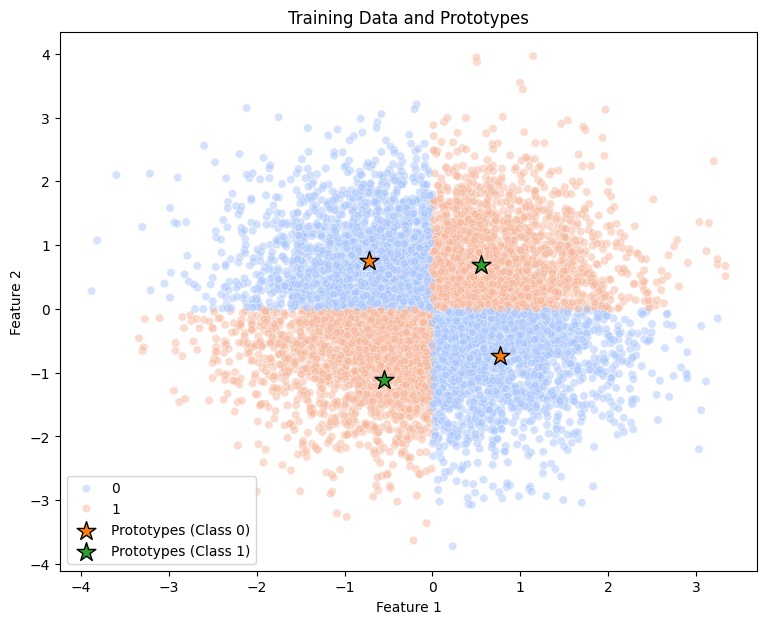

In [48]:
# Set up plot
prototypes = model_identity.proto_layer.prototypes.detach().cpu().numpy()
prototype_labels = model_identity.proto_layer.prototype_labels
plt.figure(figsize=(9, 7))

# Plot training data
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, alpha=0.5, palette="coolwarm")

# Plot prototypes
for proto_class in np.unique(prototype_labels):
    class_mask = prototype_labels == proto_class
    plt.scatter(prototypes[class_mask, 0], 
                prototypes[class_mask, 1], 
                marker='*', s=200, edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data and Prototypes")
plt.legend()
#plt.savefig('figs/ppnet/xor_example.png')
plt.show()


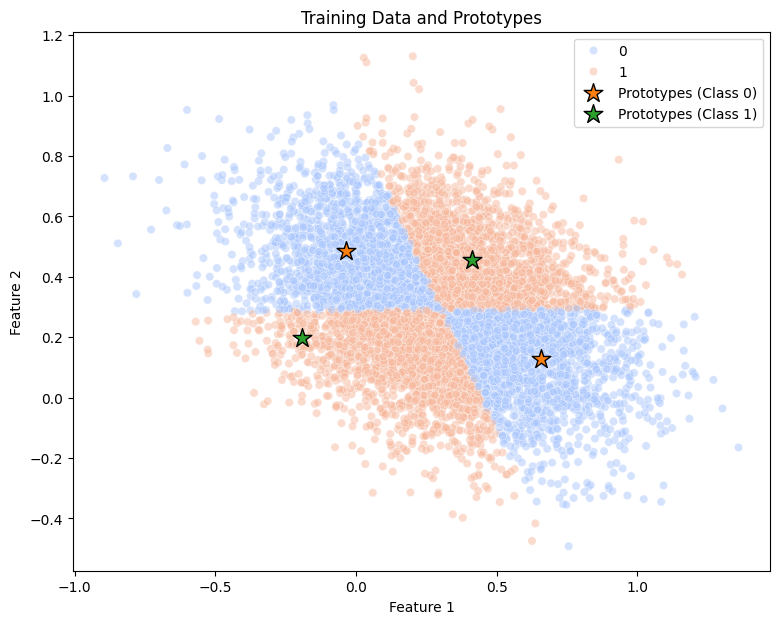

In [52]:
# Set up plot
model.eval()
with torch.no_grad():
    z_train = model_linear.encoder(X_train)

prototypes = model_linear.proto_layer.prototypes.detach().cpu().numpy()
prototype_labels = model_linear.proto_layer.prototype_labels
plt.figure(figsize=(9, 7))

# Plot training data
sns.scatterplot(x=z_train[:, 0], y=z_train[:, 1], hue=y_train, alpha=0.5, palette="coolwarm")

# Plot prototypes
for proto_class in np.unique(prototype_labels):
    class_mask = prototype_labels == proto_class
    plt.scatter(prototypes[class_mask, 0], 
                prototypes[class_mask, 1], 
                marker='*', s=200, edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data and Prototypes")
plt.legend()
#plt.savefig('figs/ppnet/xor_example.png')
plt.show()


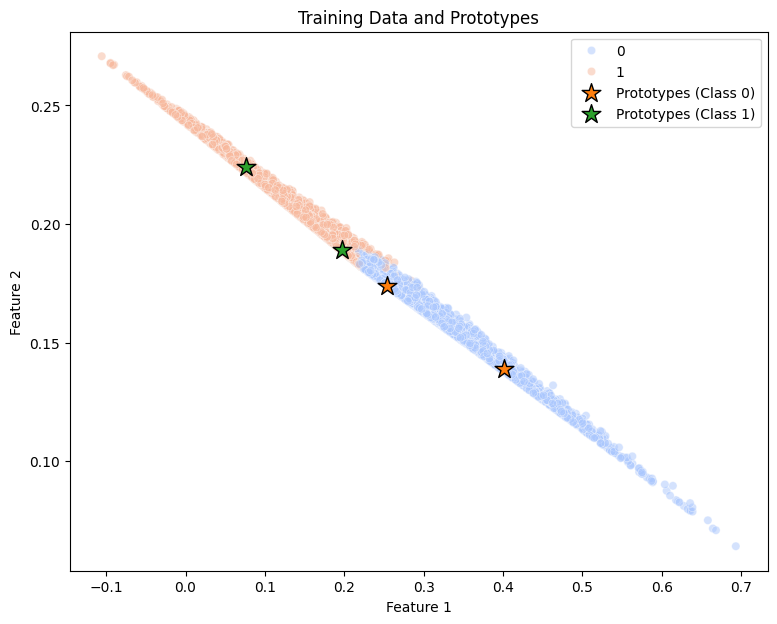

In [55]:
model.eval()
with torch.no_grad():
    z_train = model_nonlin.encoder(X_train)

prototypes = model_nonlin.proto_layer.prototypes.detach().cpu().numpy()
prototype_labels = model_nonlin.proto_layer.prototype_labels
plt.figure(figsize=(9, 7))

# Plot training data
sns.scatterplot(x=z_train[:, 0], y=z_train[:, 1], hue=y_train, alpha=0.5, palette="coolwarm")

# Plot prototypes
for proto_class in np.unique(prototype_labels):
    class_mask = prototype_labels == proto_class
    plt.scatter(prototypes[class_mask, 0], 
                prototypes[class_mask, 1], 
                marker='*', s=200, edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data and Prototypes")
plt.legend()
#plt.savefig('figs/ppnet/xor_example.png')
plt.show()


## Binary Amaretto Dataset

In [2]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

### Load data

In [7]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 2) & (pl.col('hour') < 5)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_month_cos', 'minute_cos', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly_bin'
y_train = df_train.select(target_column).to_numpy().flatten()
y_train_anomalies = df_train.select('Anomaly').to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
y_test_anomalies = df_test.select('Anomaly').to_numpy().flatten()

X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 118)
(2765755, 118)


In [8]:
train_loader = DataLoader(train_dataset, batch_size=512, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

47758


In [9]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([  0.5014, 180.1141])

### Prepare and train model

In [13]:
model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=10, num_classes=2, latent_dim=16)

In [14]:
model

ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=118, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=10, out_features=2, bias=False)
)

In [ ]:
train_protopnet(model, train_loader, val_loader, epochs=6, lr=0.0001, class_weights=class_weights, lambda_clst=0.8, lambda_sep=0.2)

In [17]:
model.load_state_dict(torch.load('model_ppnet_best_dec_10.pth'))

<All keys matched successfully>

### Model Performance and Visualization on the Training Data

In [18]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, z_train, distances, y_logits = model(X_train_tensor)
    y_probs_train = F.softmax(y_logits, dim=1)
    y_pred_train = torch.argmax(y_probs_train, dim=1)
y_pred_train = y_pred_train.cpu().numpy()
y_probs_train = y_probs_train.cpu().numpy()
print(y_pred_train.shape)
z_train = z_train.cpu().numpy()
print(z_train.shape)
print(distances.shape)

(24451934,)
(24451934, 16)
torch.Size([24451934, 10])


In [19]:
print(classification_report(y_train, y_pred_train, digits=4))

              precision    recall  f1-score   support

           0     0.9998    0.9802    0.9899  24384055
           1     0.1163    0.9350    0.2069     67879

    accuracy                         0.9801  24451934
   macro avg     0.5581    0.9576    0.5984  24451934
weighted avg     0.9974    0.9801    0.9878  24451934



In [45]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_train, y_train, n_samples=300000, anomaly_ratio=0.2)
y_pred_sampled = y_pred_train[selected_indices]
y_train_anomalies_sampled = y_train_anomalies[selected_indices]
print(z_sampled.shape)

[67879]
240000
24384055
240000
(300000, 16)


In [46]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(300000, 2)

In [47]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(20, 2)

In [26]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]

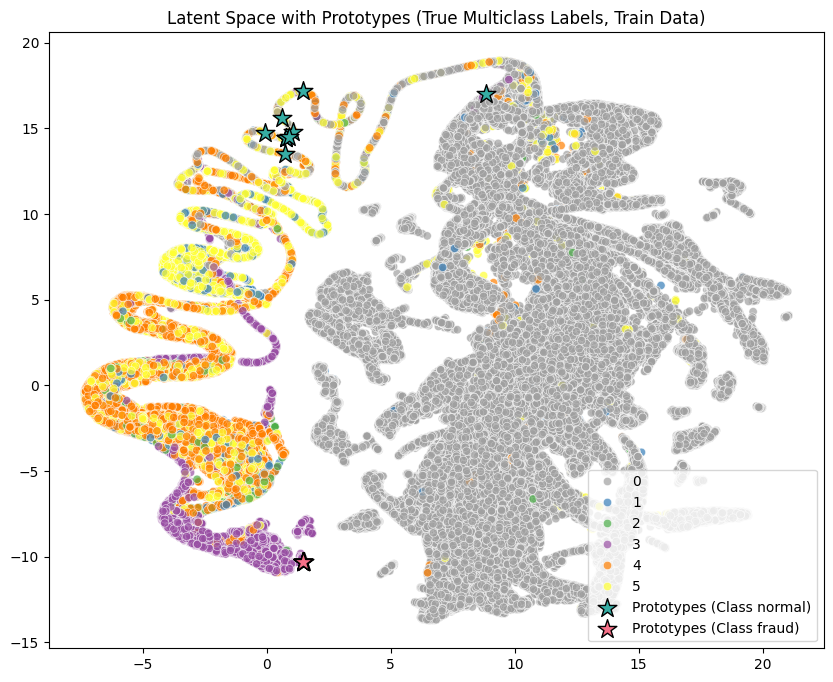

In [62]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train_anomalies_sampled, alpha=0.7, palette=custom_palette)

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=200, 
                edgecolors='black', 
                label='Prototypes (Class ' + ('normal' if proto_class == 0 else 'fraud') + ')')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes (True Multiclass Labels, Train Data)")

plt.legend(loc='lower right')
#plt.savefig('figs/ppnet/true_multi_train.png')
plt.show()

/tmp/ipykernel_2074392/2418584233.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_true_sampled, alpha=0.5, palette=custom_palette)


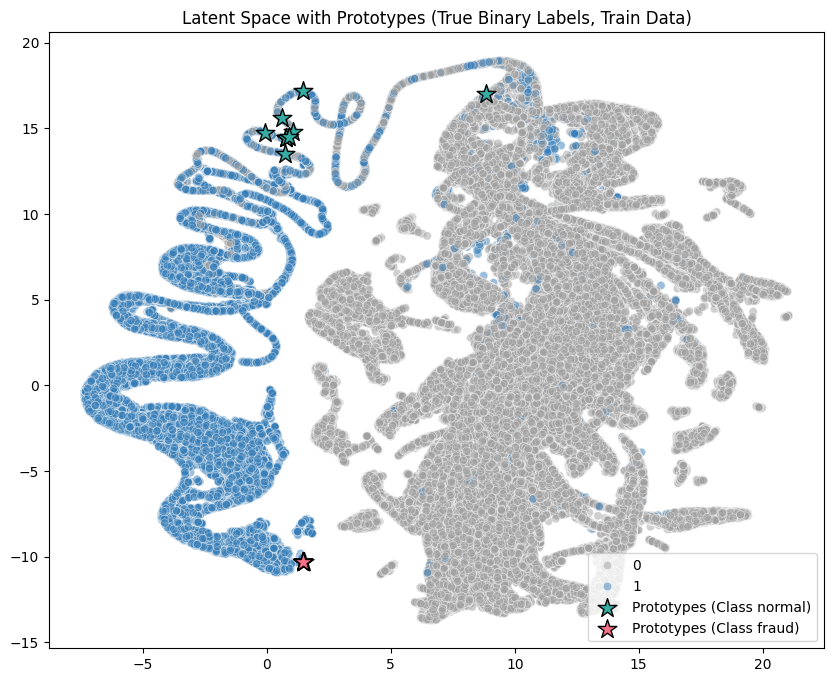

In [64]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_true_sampled, alpha=0.5, palette=custom_palette)

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=200, 
                edgecolors='black', 
                label='Prototypes (Class ' + ('normal' if proto_class == 0 else 'fraud') + ')')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes (True Binary Labels, Train Data)")

plt.legend(loc='lower right')
plt.savefig('figs/ppnet/true_bin_train.png')
plt.show()

/tmp/ipykernel_2074392/868373353.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_pred_sampled, alpha=0.5, palette=custom_palette)


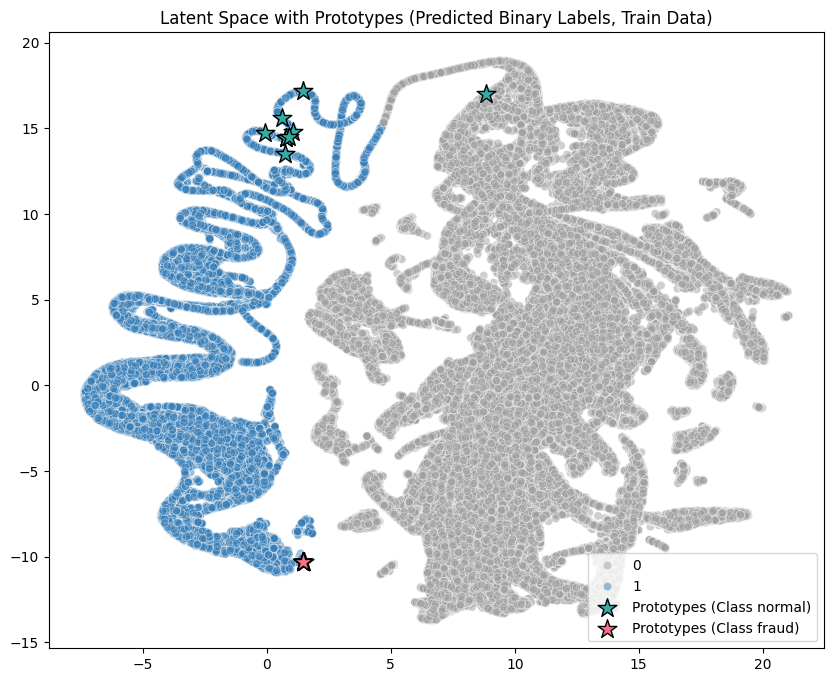

In [65]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_pred_sampled, alpha=0.5, palette=custom_palette)

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=200, 
                edgecolors='black', 
                label='Prototypes (Class ' + ('normal' if proto_class == 0 else 'fraud') + ')')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes (Predicted Binary Labels, Train Data)")

plt.legend(loc='lower right')
plt.savefig('figs/ppnet/predicted_bin_train.png')
plt.show()

### Model Performance and Visualization on the Test Data

In [20]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, z_test, distances, y_logits = model(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)
print(distances.shape)

(2765755,)
(2765755, 16)
torch.Size([2765755, 10])


In [21]:
print(classification_report(y_test, y_pred_test, digits=4))

              precision    recall  f1-score   support

           0     0.9999    0.9981    0.9990   2759074
           1     0.5507    0.9490    0.6969      6681

    accuracy                         0.9980   2765755
   macro avg     0.7753    0.9735    0.8480   2765755
weighted avg     0.9988    0.9980    0.9983   2765755



In [22]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=70000, anomaly_ratio=0.1)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]
print(z_sampled.shape)

[6681]
63000
2759074
63000
(69681, 16)


In [23]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(69681, 2)

In [24]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(10, 2)

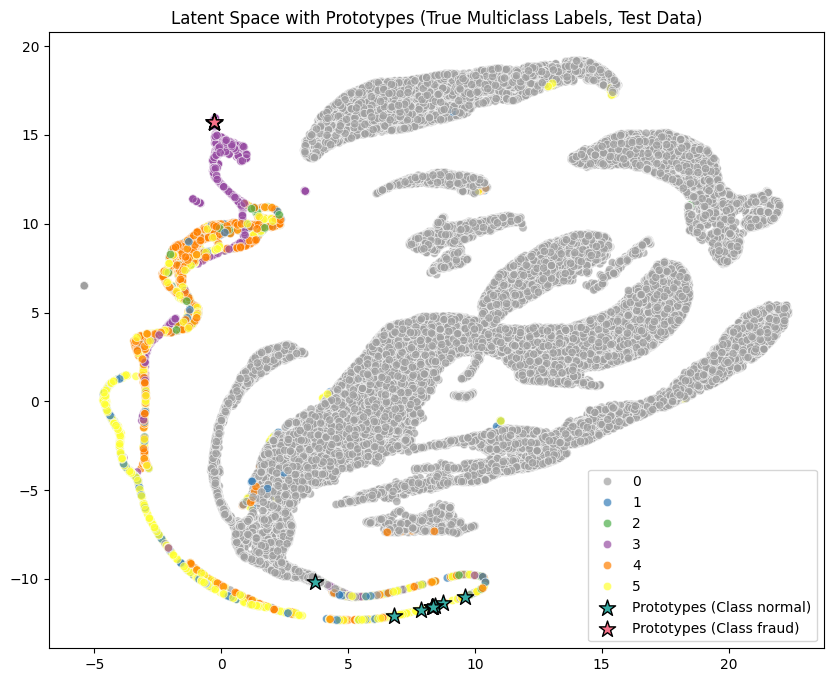

In [21]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_anomalies_sampled, alpha=0.7, palette=custom_palette)

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=150,
                alpha=1.,
                edgecolors='black', 
                label='Prototypes (Class ' + ('normal' if proto_class == 0 else 'fraud') + ')')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes (True Multiclass Labels, Test Data)")

plt.legend(loc='lower right')
plt.savefig('figs/ppnet/true_multi_test.png')
plt.show()

/tmp/ipykernel_2966214/1152694080.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_true_sampled, alpha=0.7, palette=custom_palette)


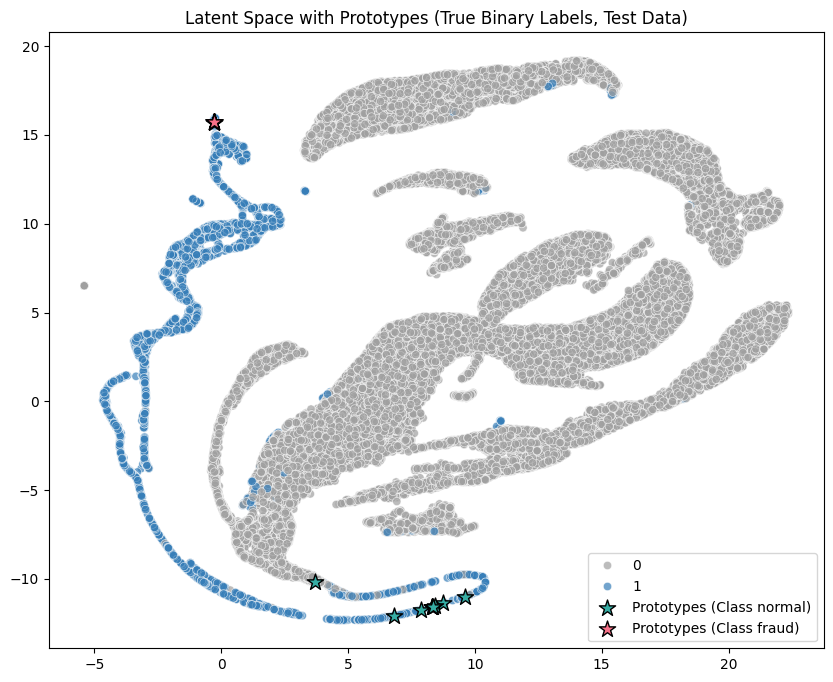

In [22]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_true_sampled, alpha=0.7, palette=custom_palette)

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=150, 
                edgecolors='black', 
                label='Prototypes (Class ' + ('normal' if proto_class == 0 else 'fraud') + ')')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes (True Binary Labels, Test Data)")

plt.legend(loc='lower right')
plt.savefig('figs/ppnet/true_bin_test.png')
plt.show()

/tmp/ipykernel_2966214/4211681511.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_pred_sampled, alpha=0.7, palette=custom_palette)


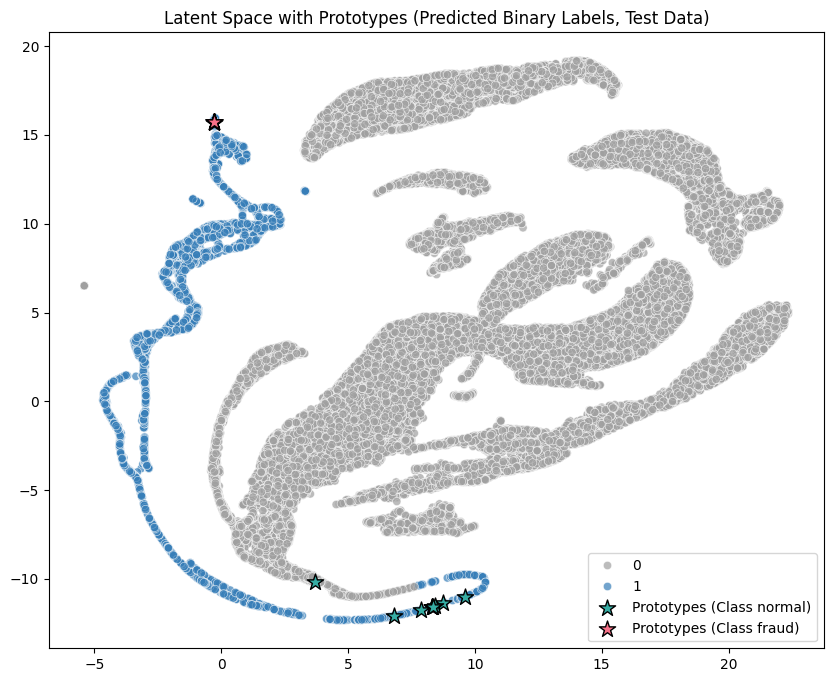

In [23]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_pred_sampled, alpha=0.7, palette=custom_palette)

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=150, 
                edgecolors='black', 
                label='Prototypes (Class ' + ('normal' if proto_class == 0 else 'fraud') + ')')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes (Predicted Binary Labels, Test Data)")

plt.legend(loc='lower right')
plt.savefig('figs/ppnet/pred_bin_test.png')
plt.show()

### Verify prototypes

In [24]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train_tensor)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

for i, dist in enumerate(distances):
    print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")

Prototype 0: Closest training point at index 3991, Distance: 0.0000
Prototype 1: Closest training point at index 14232389, Distance: 0.0000
Prototype 2: Closest training point at index 580043, Distance: 0.0000
Prototype 3: Closest training point at index 14232389, Distance: 0.0000
Prototype 4: Closest training point at index 3991, Distance: 0.0000
Prototype 5: Closest training point at index 14232389, Distance: 0.0000
Prototype 6: Closest training point at index 78299, Distance: 0.0000
Prototype 7: Closest training point at index 14232389, Distance: 0.0000
Prototype 8: Closest training point at index 3991, Distance: 0.0000
Prototype 9: Closest training point at index 14232389, Distance: 0.0000
Prototype 10: Closest training point at index 19041, Distance: 0.0000
Prototype 11: Closest training point at index 14232389, Distance: 0.0000
Prototype 12: Closest training point at index 8571183, Distance: 0.0000
Prototype 13: Closest training point at index 14232389, Distance: 0.0000
Prototype

In [26]:
# Overit spravnost trid prototypů
y_train[closest_indices]

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
      dtype=int8)

In [39]:
closest_indices[prototype_labels == 0].unique().size()

torch.Size([8])


In [40]:
closest_indices[prototype_labels == 1].unique().size()

torch.Size([1])

### Use model without prototypes and try projecting prototypes on its latent space ???

In [42]:
model_combined = CombinedModel(input_dim=X_train.shape[1], hidden_layers=[64, 64], latent_dim=16, num_classes=2)
model_combined.load_state_dict(torch.load("model_combined_best_bin.pth"))
print(model_combined)

CombinedModel(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=118, bias=True)
    )
  )
  (classifier): Classifier(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=2, bias=True)
    )
  )
)


In [45]:
model_combined.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, y_logits, z_test = model_combined(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)

(2765755,)
(2765755, 16)


In [46]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2759074
           1       0.70      0.93      0.80      6681

    accuracy                           1.00   2765755
   macro avg       0.85      0.96      0.90   2765755
weighted avg       1.00      1.00      1.00   2765755



In [49]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=70000, anomaly_ratio=0.1)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]
print(z_sampled.shape)

[6681]
63000
2759074
63000
(69681, 16)


In [50]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(69681, 2)

In [51]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(20, 2)

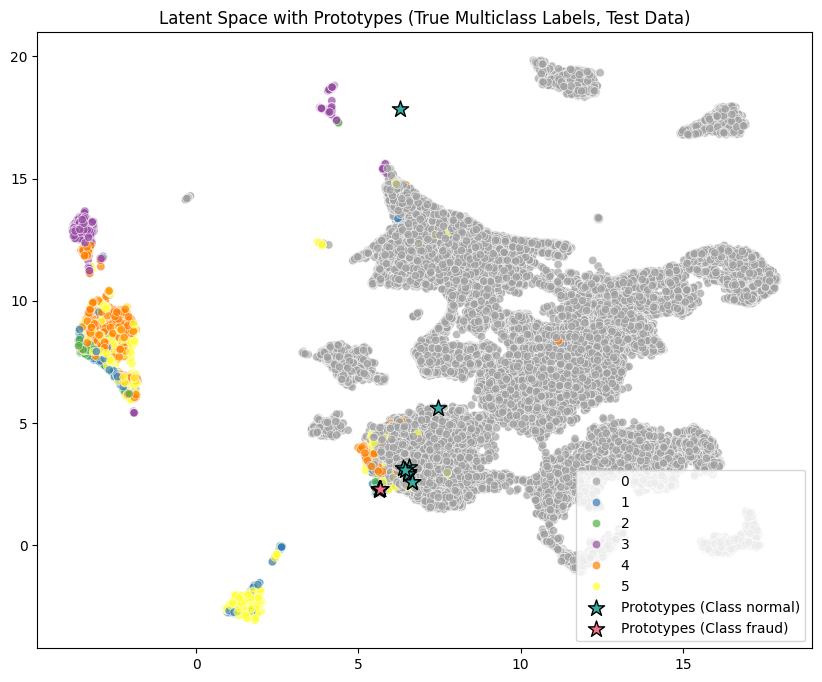

In [52]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_anomalies_sampled, alpha=0.7, palette=custom_palette)

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=150,
                alpha=1.,
                edgecolors='black', 
                label='Prototypes (Class ' + ('normal' if proto_class == 0 else 'fraud') + ')')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes (True Multiclass Labels, Test Data)")

plt.legend(loc='lower right')
#plt.savefig('figs/ppnet/true_multi_test.png')
plt.show()